# Análisis de entrenamientos iterativos 

Baselines + DistilBERT

Este notebook consolida y compara resultados de entrenamientos iterativos para:
- **Baselines**: Doc2Vec y FastText en RAW / PREPRO / PREPRO+NGRAM (10 iteraciones).
- **DistilBERT**: FE, PFT, FFT y FFT11 (5 iteraciones).

Se analizan métricas **top-1 a top-5**, curvas de entrenamiento/validación y comparaciones entre familias de modelos.

In [1]:
import os
import re
from pathlib import Path
import numpy as np
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt

sns.set_theme(style="whitegrid", context="talk")
pd.set_option('display.max_columns', 200)


## Utiles

In [2]:
TOPK_COLS = [f"top_{k}_acc" for k in range(1, 6)]

def to_long_topk(
    df: pd.DataFrame,
    id_cols: list[str],
    topk_cols: list[str] = TOPK_COLS,
    acc_name: str = "acc",
) -> pd.DataFrame:
    """
    Converts a wide metrics DF with columns top_1_acc...top_5_acc into a long DF:
      id_cols + ['topk', acc_name]
    """
    missing = [c for c in topk_cols if c not in df.columns]
    if missing:
        raise ValueError(f"Missing top-k columns: {missing}")

    out = df.melt(
        id_vars=id_cols,
        value_vars=topk_cols,
        var_name="topk",
        value_name=acc_name,
    ).copy()

    # 'top_3_acc' -> 3
    out["topk"] = out["topk"].str.extract(r"top_(\d+)_acc").astype(int)
    return out


def plot_topk_variability(
    df_long: pd.DataFrame,
    group_col: str,
    iteration_col: str = "iteration",
    x_col: str = "topk",
    y_col: str = "acc",
    groups: list[str] | None = None,
    title: str | None = None,
    show_iteration_lines: bool = False,
    show_mean: bool = True,
    show_std_band: bool = True,
    std_band_k: float = 3,
    alpha_iter: float = 0.7,
    alpha_band: float = 0.5,
    linewidth_iter: float = 1.0,
    linewidth_mean: float = 2.5,
    marker: str = "o",
    figsize: tuple[int, int] = (9, 5),
):
    """
    Generic plot for top-k accuracy with variability across iterations.
    Expects df_long with columns: group_col, iteration_col, x_col(=topk), y_col(=acc).
    """
    needed = {group_col, iteration_col, x_col, y_col}
    missing = needed - set(df_long.columns)
    if missing:
        raise ValueError(f"df_long missing columns: {sorted(missing)}")

    data = df_long.copy()
    if groups is not None:
        data = data[data[group_col].isin(groups)].copy()

    data = data.sort_values([group_col, iteration_col, x_col])

    fig, ax = plt.subplots(figsize=figsize)

    # Iterate groups (matplotlib default color cycle)
    for g, gdf in data.groupby(group_col, sort=False):
        # 1) per-iteration lines
        if show_iteration_lines:
            for it, itdf in gdf.groupby(iteration_col, sort=False):
                ax.plot(
                    itdf[x_col].values,
                    itdf[y_col].values,
                    alpha=alpha_iter,
                    linewidth=linewidth_iter,
                )

        # 2) mean + std band
        stats = (
            gdf.groupby(x_col)[y_col]
            .agg(["mean", "std"])
            .reset_index()
            .sort_values(x_col)
        )

        if show_std_band:
            m = stats["mean"].to_numpy()
            s = stats["std"].fillna(0.0).to_numpy()
            x = stats[x_col].to_numpy()
            ax.fill_between(
                x,
                m - std_band_k * s,
                m + std_band_k * s,
                alpha=alpha_band,
                linewidth=0.0,
            )

        if show_mean:
            ax.plot(
                stats[x_col].values,
                stats["mean"].values,
                marker=marker,
                ms=5,
                linewidth=linewidth_mean,
                label=str(g),

            )

    ax.set_xlabel("top-k")
    ax.set_ylabel("accuracy")
    ax.set_xticks(sorted(data[x_col].unique()))
    ax.set_ylim(0.0, 1.0)
    ax.grid(True, alpha=0.25)

    if title:
        ax.set_title(title)

    ax.legend(title=group_col, bbox_to_anchor=(1.02, 1), loc="upper left")
    plt.tight_layout()
    plt.show()


def select_best_epoch_by_mean_over_runs(
    df_epochs: pd.DataFrame,
    group_cols: list[str],           # e.g. ["train_type"]
    epoch_col: str = "epoch",
    metric_col: str = "val_top5",
    agg: str = "mean",               # "mean" or "median"
    tie_break: str = "earliest",     # "earliest" or "latest"
    min_runs: int = 1,               # require at least this many runs at that epoch
) -> pd.DataFrame:
    """
    Picks best epoch per group by aggregating metric across runs (seeds/iterations).

    Output columns:
      group_cols + ["best_epoch", f"best_{agg}_{metric_col}", "n_runs"]
    """
    needed = set(group_cols + [epoch_col, metric_col])
    missing = needed - set(df_epochs.columns)
    if missing:
        raise ValueError(f"df_epochs missing columns: {sorted(missing)}")

    tmp = df_epochs.copy()

    # Aggregate across runs for each (group, epoch)
    if agg == "mean":
        agg_df = (
            tmp.groupby(group_cols + [epoch_col])[metric_col]
            .agg(["mean", "std", "count"])
            .reset_index()
            .rename(columns={"mean": "agg_metric", "std": "agg_std", "count": "n_runs"})
        )
    elif agg == "median":
        agg_df = (
            tmp.groupby(group_cols + [epoch_col])[metric_col]
            .agg(["median", "count"])
            .reset_index()
            .rename(columns={"median": "agg_metric", "count": "n_runs"})
        )
        agg_df["agg_std"] = np.nan
    else:
        raise ValueError("agg must be 'mean' or 'median'")

    # Optional: enforce minimum number of runs per epoch
    agg_df = agg_df[agg_df["n_runs"] >= min_runs].copy()
    if agg_df.empty:
        raise ValueError("After applying min_runs filter, no rows remain.")

    # Sort to pick best epoch:
    # primary: agg_metric desc
    # secondary: epoch asc/desc depending tie_break
    epoch_asc = True if tie_break == "earliest" else False

    agg_df = agg_df.sort_values(
        group_cols + ["agg_metric", epoch_col],
        ascending=[True]*len(group_cols) + [False, epoch_asc],
    )

    best = agg_df.groupby(group_cols, as_index=False).head(1).reset_index(drop=True)
    best = best.rename(columns={
        epoch_col: "best_epoch",
        "agg_metric": f"best_{agg}_{metric_col}",
    })
    return best[group_cols + ["best_epoch", f"best_{agg}_{metric_col}", "n_runs"]]


def filter_metrics_to_best_epoch(
    df_metrics_epochs: pd.DataFrame,
    best_epoch_df: pd.DataFrame,
    group_cols: list[str],           # e.g. ["train_type"]
    epoch_col: str = "epoch",
) -> pd.DataFrame:
    """
    Filters per-run metrics DF (contains epoch) to the best epoch per group.
    """
    needed = set(group_cols + [epoch_col])
    missing = needed - set(df_metrics_epochs.columns)
    if missing:
        raise ValueError(f"df_metrics_epochs missing columns: {sorted(missing)}")

    needed2 = set(group_cols + ["best_epoch"])
    missing2 = needed2 - set(best_epoch_df.columns)
    if missing2:
        raise ValueError(f"best_epoch_df missing columns: {sorted(missing2)}")

    merged = df_metrics_epochs.merge(best_epoch_df[group_cols + ["best_epoch"]], on=group_cols, how="inner")
    out = merged[merged[epoch_col] == merged["best_epoch"]].copy()
    return out


def summarize_groups(
    df: pd.DataFrame,
    group_col: str,
    topk_cols: list[str] = TOPK_COLS,
) -> pd.DataFrame:
    """
    Returns per-group mean/std for each top-k and an overall score columns.
    """
    missing = [c for c in topk_cols + [group_col] if c not in df.columns]
    if missing:
        raise ValueError(f"Missing columns: {missing}")

    agg = df.groupby(group_col)[topk_cols].agg(["mean", "std"])
    # flatten columns: ('top_1_acc','mean') -> 'top_1_acc_mean'
    agg.columns = [f"{c}_{s}" for c, s in agg.columns]
    agg = agg.reset_index()

    # convenient scores
    agg["score_top1_mean"] = agg["top_1_acc_mean"]
    agg["score_top5_mean"] = agg["top_5_acc_mean"]
    return agg.sort_values("score_top1_mean", ascending=False).reset_index(drop=True)


def build_delta_df(
    df_long: pd.DataFrame,
    group_col: str,
    group_a: str,
    group_b: str,
    iteration_col: str = "iteration",
    x_col: str = "topk",
    y_col: str = "acc",
    delta_name: str = "delta",
    direction_label: str | None = None,
) -> tuple[pd.DataFrame, pd.DataFrame]:
    """
    Returns:
      - delta_long: per-iteration delta rows with columns:
          [iteration_col, x_col, 'acc_a', 'acc_b', delta_name, 'A', 'B', 'direction']
      - delta_summary: per-topk summary stats of delta

    Delta definition: delta = acc(group_b) - acc(group_a)
    """
    need = {group_col, iteration_col, x_col, y_col}
    missing = need - set(df_long.columns)
    if missing:
        raise ValueError(f"df_long missing columns: {sorted(missing)}")

    a = df_long[df_long[group_col] == group_a][[iteration_col, x_col, y_col]].copy()
    b = df_long[df_long[group_col] == group_b][[iteration_col, x_col, y_col]].copy()

    a = a.rename(columns={y_col: "acc_a"})
    b = b.rename(columns={y_col: "acc_b"})

    merged = a.merge(b, on=[iteration_col, x_col], how="inner")

    if merged.empty:
        # Helpful error if iteration indexes don't match, etc.
        raise ValueError(
            f"No aligned rows after merge. Check that both groups share the same "
            f"{iteration_col} and {x_col} values."
        )

    merged[delta_name] = merged["acc_b"] - merged["acc_a"]
    merged["A"] = group_a
    merged["B"] = group_b
    merged["direction"] = direction_label or f"{group_b} - {group_a}"

    # Summary per topk
    g = merged.groupby(x_col)[delta_name]
    delta_summary = pd.DataFrame({
        x_col: g.mean().index,
        "n": g.count().values,
        "mean": g.mean().values,
        "std": g.std().values,
        "median": g.median().values,
        "q25": g.quantile(0.25).values,
        "q75": g.quantile(0.75).values,
        "min": g.min().values,
        "max": g.max().values,
    }).sort_values(x_col).reset_index(drop=True)

    delta_long = merged.sort_values([iteration_col, x_col]).reset_index(drop=True)
    return delta_long, delta_summary


def plot_delta_variability(
    delta_long: pd.DataFrame,
    x_col: str = "topk",
    delta_col: str = "delta",
    iteration_col: str = "iteration",
    title: str | None = None,
    mode: str = "scatter",     # "scatter" or "spaghetti"
    band: str = "iqr",         # "iqr", "std", or None
    band_k: float = 1.0,
    jitter_x: float = 0.10,
    alpha_points: float = 0.25,
    size_points: float = 18,
    alpha_iter: float = 0.12,
    linewidth_iter: float = 1.0,
    linewidth_mean: float = 2.8,
    alpha_band: float = 0.20,
    seed: int = 123,
    figsize=(9, 4.5),
):
    need = {x_col, delta_col, iteration_col}
    missing = need - set(delta_long.columns)
    if missing:
        raise ValueError(f"delta_long missing columns: {sorted(missing)}")

    data = delta_long.copy().sort_values([iteration_col, x_col])
    rng = np.random.default_rng(seed)

    fig, ax = plt.subplots(figsize=figsize)

    # Variability
    if mode == "spaghetti":
        for it, itdf in data.groupby(iteration_col, sort=False):
            x = itdf[x_col].to_numpy(dtype=float)
            if jitter_x and jitter_x > 0:
                x = x + rng.normal(0.0, jitter_x, size=len(x))
            y = itdf[delta_col].to_numpy(dtype=float)
            ax.plot(x, y, alpha=alpha_iter, linewidth=linewidth_iter)
    elif mode == "scatter":
        x = data[x_col].to_numpy(dtype=float)
        y = data[delta_col].to_numpy(dtype=float)
        xj = x + rng.normal(0.0, jitter_x, size=len(x)) if jitter_x else x
        ax.scatter(xj, y, alpha=alpha_points, s=size_points)
    else:
        raise ValueError("mode must be 'scatter' or 'spaghetti'")

    # Summary line + band
    grouped = data.groupby(x_col)[delta_col]
    mean = grouped.mean()
    xk = mean.index.to_numpy()
    m = mean.to_numpy()

    if band is not None:
        if band.lower() == "std":
            s = grouped.std().fillna(0.0).to_numpy()
            lo, hi = m - band_k * s, m + band_k * s
        elif band.lower() == "iqr":
            lo = grouped.quantile(0.25).to_numpy()
            hi = grouped.quantile(0.75).to_numpy()
        else:
            raise ValueError("band must be one of: 'std', 'iqr', None")

        ax.fill_between(xk, lo, hi, alpha=alpha_band, linewidth=0.0)

    ax.plot(xk, m, linewidth=linewidth_mean)

    # Reference line at 0 delta
    ax.axhline(0.0, linewidth=1.2, alpha=0.6)

    ax.set_xlabel("top-k")
    ax.set_ylabel("Δ accuracy (B - A)")
    ax.set_xticks(sorted(data[x_col].unique()))
    ax.grid(True, alpha=0.22)

    if title:
        ax.set_title(title)

    plt.tight_layout()
    plt.show()

## Carga y normalización de resultados

In [3]:
BASE_DIR = Path('results')
BASELINES_DIR = BASE_DIR / 'baselines'
DISTILBERT_DIR = BASE_DIR / 'distilbert'

assert BASELINES_DIR.exists(), f"No existe {BASELINES_DIR}"
assert DISTILBERT_DIR.exists(), f"No existe {DISTILBERT_DIR}"


### Baselines

In [4]:
baseline_files = sorted(BASELINES_DIR.glob('*.csv'))
baseline_files

[WindowsPath('results/baselines/scored_dfs_D2V_GOODS_DESCRIPTION_HS04_seed503070489.csv'),
 WindowsPath('results/baselines/scored_dfs_D2V_PREPRO_DESCRIPTION_HS04_seed503070489.csv'),
 WindowsPath('results/baselines/scored_dfs_D2V_PREPRO_DESCRIPTION_NGRAM_DESCRIPTION_HS04_seed503070489.csv'),
 WindowsPath('results/baselines/scored_dfs_FT_GOODS_DESCRIPTION_HS04_seed503070489.csv'),
 WindowsPath('results/baselines/scored_dfs_FT_PREPRO_DESCRIPTION_HS04_seed503070489.csv'),
 WindowsPath('results/baselines/scored_dfs_FT_PREPRO_DESCRIPTION_NGRAM_DESCRIPTION_HS04_seed503070489.csv')]

In [5]:
def parse_baseline_filename(path: Path):
    name = path.stem
    # scored_dfs_<MODEL>_<TEXTCOL>_HS04_seed...
    payload = name.replace('scored_dfs_', '')
    if payload.startswith('D2V_'):
        model = 'D2V'
        rest = payload[len('D2V_'):]
    elif payload.startswith('FT_'):
        model = 'FT'
        rest = payload[len('FT_'):]
    else:
        model = 'UNKNOWN'
        rest = payload

    # remover sufijo _HS04_seed...
    rest = re.sub(r'_HS04_seed\d+$', '', rest)

    text_type = {
        'GOODS_DESCRIPTION': 'RAW',
        'PREPRO_DESCRIPTION': 'PREPRO',
        'PREPRO_DESCRIPTION_NGRAM_DESCRIPTION': 'PREPRO+NGRAM'
    }.get(rest, rest)
    return model, text_type

In [6]:
baseline_rows = []
for f in baseline_files:
    model, text_type = parse_baseline_filename(f)
    df = pd.read_csv(f).copy()
    df['iteration'] = np.arange(1, len(df)+1)
    df['model'] = model
    df['text_type'] = text_type
    df['family'] = df['model'] + '_' + df['text_type']
    baseline_rows.append(df)

baseline = pd.concat(baseline_rows, ignore_index=True)


### Distilbert

In [7]:
metrics_files = {
    'fe': DISTILBERT_DIR / 'fe' / 'metrics_fe_GOODS_DESCRIPTION_HS04.csv',
    'pft': DISTILBERT_DIR / 'pft' / 'metrics_pft_GOODS_DESCRIPTION_HS04.csv',
    'fft': DISTILBERT_DIR / 'fft' / 'metrics_fft_GOODS_DESCRIPTION_HS04.csv',
    'fft11': DISTILBERT_DIR / 'fft11' / 'experiments_job_fft_v11_metrics_fft_GOODS_DESCRIPTION_HS04.csv',
}
history_files = {
    'fe': DISTILBERT_DIR / 'fe' / 'history_all_iters_fe.csv',
    'pft': DISTILBERT_DIR / 'pft' / 'history_all_iters_pft.csv',
    'fft': DISTILBERT_DIR / 'fft' / 'history_all_iters_fft.csv',
    'fft11': DISTILBERT_DIR / 'fft11' / 'experiments_job_fft_v11_history_all_iters_fft.csv',
}

for k, v in {**metrics_files, **history_files}.items():
    assert v.exists(), f"Falta archivo de {k}: {v}"

dist_metrics = []
for train_type, f in metrics_files.items():
    df = pd.read_csv(f).copy()
    df['train_type'] = train_type.upper()
    df['iteration'] = np.arange(1, len(df)+1)
    dist_metrics.append(df)

dist_metrics = pd.concat(dist_metrics, ignore_index=True)
dist_metrics


,model,top_1_acc,top_2_acc,top_3_acc,top_4_acc,top_5_acc,train_type,iteration
0,DBERT_fe_GOODS_DESCRIPTION_HS04_seed31187689,0.523863,0.625439,0.676301,0.710583,0.736351,FE,1
1,DBERT_fe_GOODS_DESCRIPTION_HS04_seed491185480,0.525655,0.629845,0.679812,0.709239,0.732542,FE,2
2,DBERT_fe_GOODS_DESCRIPTION_HS04_seed737166323,0.526402,0.627455,0.678617,0.710135,0.735230,FE,3
3,DBERT_fe_GOODS_DESCRIPTION_HS04_seed95156473,0.523415,0.624318,0.673165,0.708716,0.733662,FE,4
4,DBERT_fe_GOODS_DESCRIPTION_HS04_seed954562093,0.534095,0.635895,0.688625,0.723206,0.747479,FE,5
5,DBERT_pft_GOODS_DESCRIPTION_HS04_seed140871553,0.651356,0.750317,0.793935,0.817537,0.836134,PFT,1
6,DBERT_pft_GOODS_DESCRIPTION_HS04_seed320099395,0.655165,0.745537,0.789529,0.815072,0.832250,PFT,2
7,DBERT_pft_GOODS_DESCRIPTION_HS04_seed420029892,0.648742,0.747405,0.792292,0.816342,0.833744,PFT,3
8,DBERT_pft_GOODS_DESCRIPTION_HS04_seed550264748,0.648144,0.743446,0.787736,0.812159,0.830981,PFT,4
9,DBERT_pft_GOODS_DESCRIPTION_HS04_seed748447230,0.650011,0.744641,0.787213,0.812757,0.832101,PFT,5


## Performance

### Baselines

In [8]:
print(baseline.to_markdown())

|    |   top_1_acc |   top_2_acc |   top_3_acc |   top_4_acc |   top_5_acc |   iteration | model   | text_type    | family           |
|---:|------------:|------------:|------------:|------------:|------------:|------------:|:--------|:-------------|:-----------------|
|  0 |    0.519083 |    0.613339 |    0.654791 |    0.682127 |    0.700799 |           1 | D2V     | RAW          | D2V_RAW          |
|  1 |    0.514228 |    0.604825 |    0.649563 |    0.678393 |    0.697662 |           2 | D2V     | RAW          | D2V_RAW          |
|  2 |    0.513033 |    0.605945 |    0.64792  |    0.675704 |    0.694675 |           3 | D2V     | RAW          | D2V_RAW          |
|  3 |    0.510643 |    0.604601 |    0.650235 |    0.677496 |    0.695422 |           4 | D2V     | RAW          | D2V_RAW          |
|  4 |    0.51012  |    0.600269 |    0.646202 |    0.671073 |    0.689447 |           5 | D2V     | RAW          | D2V_RAW          |
|  5 |    0.514377 |    0.602136 |    0.645605 |    0.6

In [9]:
baseline_summary = (
    baseline
    .groupby('family')[['top_1_acc','top_2_acc','top_3_acc','top_4_acc','top_5_acc']]
    .agg(['mean','std','min','max'])
    .round(4)
)
baseline_summary

top_1_acc                         top_2_acc                  \
                      mean     std     min     max      mean     std     min   
family                                                                         
D2V_PREPRO          0.4745  0.0056  0.4637  0.4836    0.5568  0.0058  0.5440   
D2V_PREPRO+NGRAM    0.6084  0.0072  0.5959  0.6213    0.6848  0.0065  0.6739   
D2V_RAW             0.5120  0.0046  0.5015  0.5191    0.6044  0.0056  0.5924   
FT_PREPRO           0.5766  0.0053  0.5685  0.5864    0.7056  0.0045  0.6998   
FT_PREPRO+NGRAM     0.5784  0.0048  0.5714  0.5836    0.7052  0.0046  0.6989   
FT_RAW              0.5370  0.0049  0.5307  0.5480    0.6615  0.0048  0.6564   

                         top_3_acc                         top_4_acc          \
                     max      mean     std     min     max      mean     std   
family                                                                         
D2V_PREPRO        0.5643    0.5968  0.0051  0.5862  0.6040    0.6225  0.0051   
D2V_PREPRO+NGRAM  0.6955    0.7149  0.0049  0.7071  0.7238    0.7315  0.0047   
D2V_RAW           0.6133    0.6486  0.0036  0.6417  0.6548    0.6752  0.0043   
FT_PREPRO         0.7151    0.7637  0.0042  0.7581  0.7715    0.7980  0.0041   
FT_PREPRO+NGRAM   0.7135    0.7628  0.0041  0.7563  0.7701    0.7965  0.0037   
FT_RAW            0.6726    0.7188  0.0049  0.7118  0.7305    0.7537  0.0040   

                                 top_5_acc                          
                     min     max      mean     std     min     max  
family                                                              
D2V_PREPRO        0.6126  0.6287    0.6409  0.0053  0.6305  0.6487  
D2V_PREPRO+NGRAM  0.7239  0.7397    0.7431  0.0045  0.7352  0.7511  
D2V_RAW           0.6670  0.6821    0.6937  0.0040  0.6877  0.7008  
FT_PREPRO         0.7907  0.8041    0.8205  0.0038  0.8157  0.8279  
FT_PREPRO+NGRAM   0.7912  0.8035    0.8197  0.0036  0.8146  0.8262  
FT_RAW            0.7488  0.7631    0.7773  0.0033  0.7731  0.7846

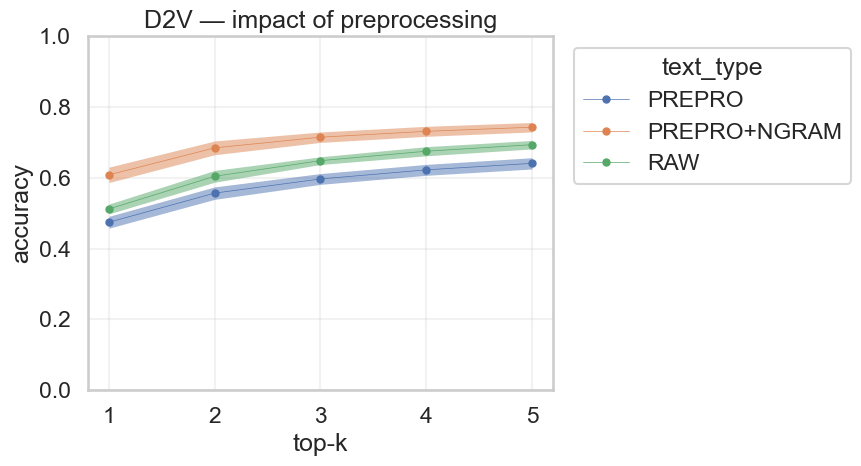

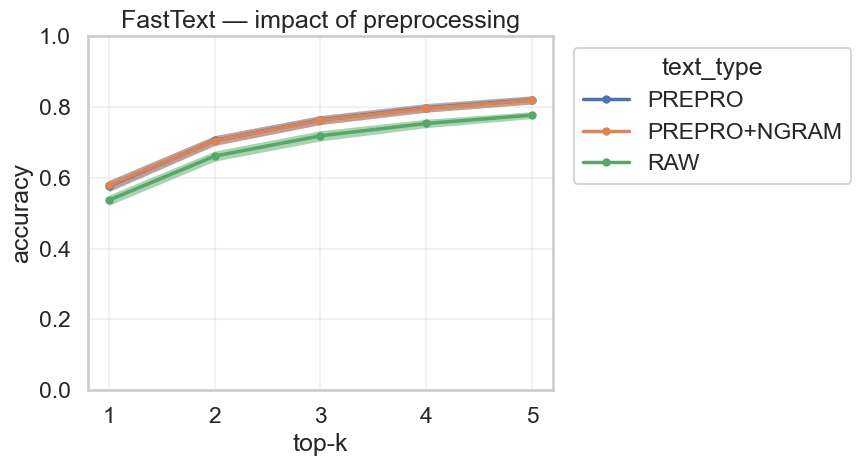

In [10]:
baseline_long = to_long_topk(
    baseline,
    id_cols=["iteration", "model", "text_type", "family"],
    topk_cols=TOPK_COLS,
    acc_name="acc",
)

plot_topk_variability(
    baseline_long[baseline_long["model"] == "D2V"],
    group_col="text_type",
    title="D2V — impact of preprocessing",
    alpha_band=0.5,
    linewidth_mean=0.5,
)

plot_topk_variability(
    baseline_long[baseline_long["model"] == "FT"],
    group_col="text_type",
    title="FastText — impact of preprocessing",
)

In [11]:
baseline_summary = summarize_groups(baseline, group_col="family")
baseline_summary

,family,top_1_acc_mean,top_1_acc_std,top_2_acc_mean,top_2_acc_std,top_3_acc_mean,top_3_acc_std,top_4_acc_mean,top_4_acc_std,top_5_acc_mean,top_5_acc_std,score_top1_mean,score_top5_mean
0,D2V_PREPRO+NGRAM,0.608432,0.007236,0.684756,0.006488,0.714870,0.004904,0.731481,0.004722,0.743080,0.004462,0.608432,0.743080
1,FT_PREPRO+NGRAM,0.578437,0.004843,0.705183,0.004626,0.762760,0.004065,0.796467,0.003673,0.819680,0.003553,0.578437,0.819680
2,FT_PREPRO,0.576563,0.005301,0.705587,0.004508,0.763664,0.004241,0.797961,0.004057,0.820487,0.003848,0.576563,0.820487
3,FT_RAW,0.536993,0.004873,0.661453,0.004756,0.718762,0.004856,0.753716,0.003984,0.777272,0.003265,0.536993,0.777272
4,D2V_RAW,0.512032,0.004606,0.604354,0.005552,0.648555,0.003643,0.675196,0.004304,0.693719,0.003984,0.512032,0.693719
5,D2V_PREPRO,0.474457,0.005579,0.556785,0.005842,0.596833,0.005090,0.622533,0.005149,0.640937,0.005305,0.474457,0.640937


Mejores baselines por modelo:

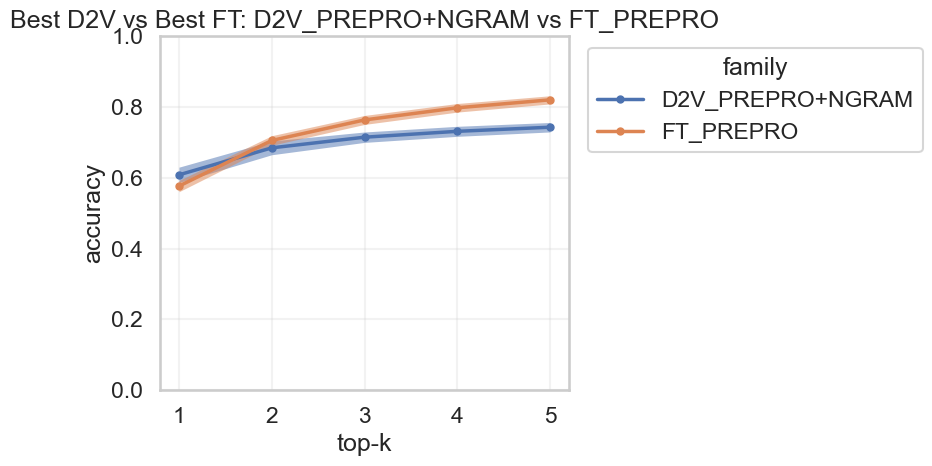

In [12]:
best_d2v = "D2V_PREPRO+NGRAM"
best_ft = "FT_PREPRO"

plot_topk_variability(
    baseline_long[baseline_long["family"].isin([best_d2v, best_ft])],
    group_col="family",
    title=f"Best D2V vs Best FT: {best_d2v} vs {best_ft}",
)

In [13]:
sub = baseline_long[baseline_long["family"].isin([best_d2v, best_ft])].copy()

# Here choose A and B direction (e.g. FT - D2V)
delta_long, delta_summary = build_delta_df(
    sub,
    group_col="family",
    group_a=best_d2v,
    group_b=best_ft,
    iteration_col="iteration",
    x_col="topk",
    y_col="acc",
    delta_name="delta",
)

delta_summary

,topk,n,mean,std,median,q25,q75,min,max
0,1,10,-0.031869,0.005411,-0.031742,-0.034561,-0.028437,-0.042871,-0.023303
1,2,10,0.020831,0.004201,0.020129,0.018560,0.023863,0.013892,0.026962
2,3,10,0.048794,0.003402,0.049593,0.045915,0.051666,0.043245,0.053029
3,4,10,0.066480,0.003137,0.066025,0.063989,0.068171,0.062365,0.071402
4,5,10,0.077407,0.003129,0.077115,0.075454,0.078609,0.072821,0.082830


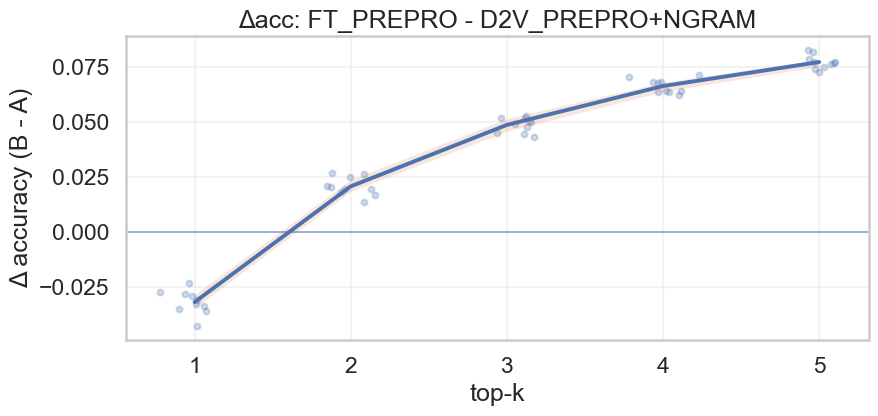

In [14]:
plot_delta_variability(
    delta_long,
    title=f"Δacc: {best_ft} - {best_d2v}",
    mode="scatter",
    band="iqr",
    jitter_x=0.10,
)

In [15]:
best_baseline = "FT_PREPRO"

## Curvas de entrenamiento DistilBERT

In [16]:
history_rows = []
for train_type, f in history_files.items():
    df = pd.read_csv(f).copy()
    df['train_type'] = train_type.upper()
    df['iteration'] = df['iteration'] + 1
    history_rows.append(df)

dist_history = pd.concat(history_rows, ignore_index=True)
dist_history.head()

,iteration,seed,epoch,train_loss,train_acc,train_top1_acc,train_top2_acc,train_top3_acc,train_top4_acc,train_top5_acc,val_loss,val_acc,val_top1_acc,val_top2_acc,val_top3_acc,val_top4_acc,val_top5_acc,train_type
0,1,491185480,1,3.556737,0.334933,0.334933,0.425275,0.476527,0.511922,0.539692,2.716067,0.446785,0.446785,0.547390,0.597655,0.635148,0.661438,FE
1,1,491185480,2,2.819426,0.424199,0.424199,0.526869,0.581612,0.618844,0.646599,2.554040,0.471581,0.471581,0.574352,0.626186,0.661214,0.686235,FE
2,1,491185480,3,2.694364,0.441761,0.441761,0.546139,0.601510,0.638354,0.665857,2.487311,0.478677,0.478677,0.586003,0.638360,0.671820,0.696318,FE
3,1,491185480,4,2.632907,0.450995,0.450995,0.555719,0.611675,0.647902,0.675378,2.452231,0.486743,0.486743,0.591829,0.645903,0.677198,0.702517,FE
4,1,491185480,5,2.590887,0.456527,0.456527,0.562853,0.618342,0.654208,0.681679,2.418344,0.498768,0.498768,0.599746,0.649862,0.680559,0.705280,FE


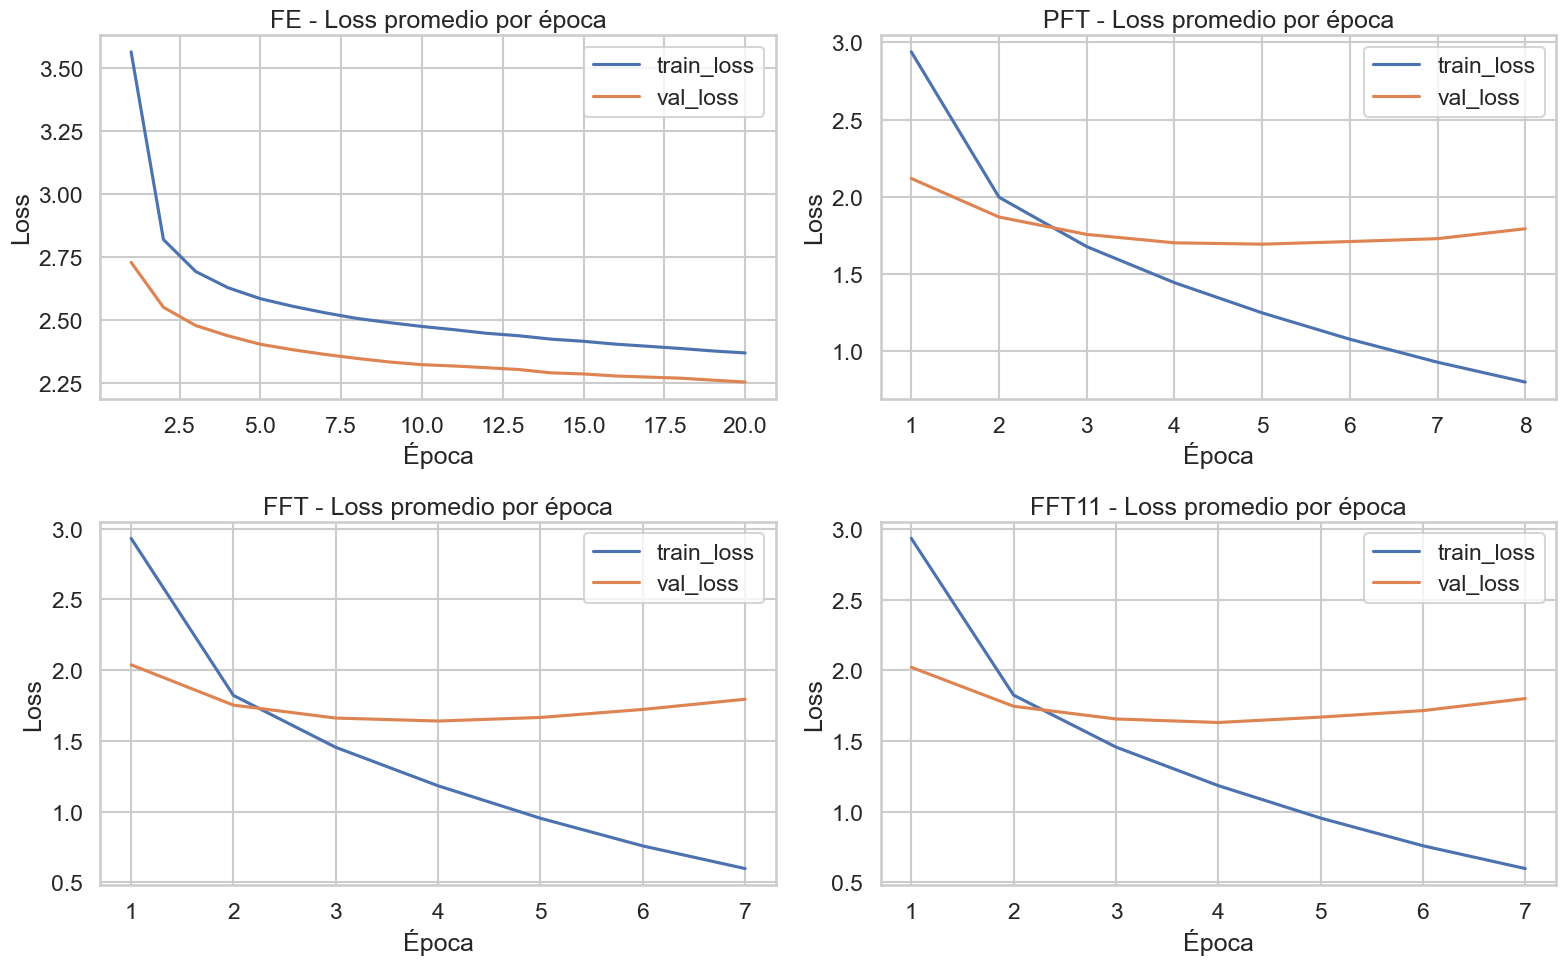

In [17]:

fig, axes = plt.subplots(2, 2, figsize=(16,10), sharex=False)
axes = axes.flatten()
for ax, train_type in zip(axes, ['FE','PFT','FFT','FFT11']):
    df = dist_history[dist_history['train_type']==train_type]
    mean_by_epoch = df.groupby('epoch')[['train_loss','val_loss']].mean().reset_index()
    sns.lineplot(data=mean_by_epoch, x='epoch', y='train_loss', label='train_loss', ax=ax)
    sns.lineplot(data=mean_by_epoch, x='epoch', y='val_loss', label='val_loss', ax=ax)
    ax.set_title(f'{train_type} - Loss promedio por época')
    ax.set_xlabel('Época')
    ax.set_ylabel('Loss')
    ax.legend()
plt.tight_layout()
plt.show()


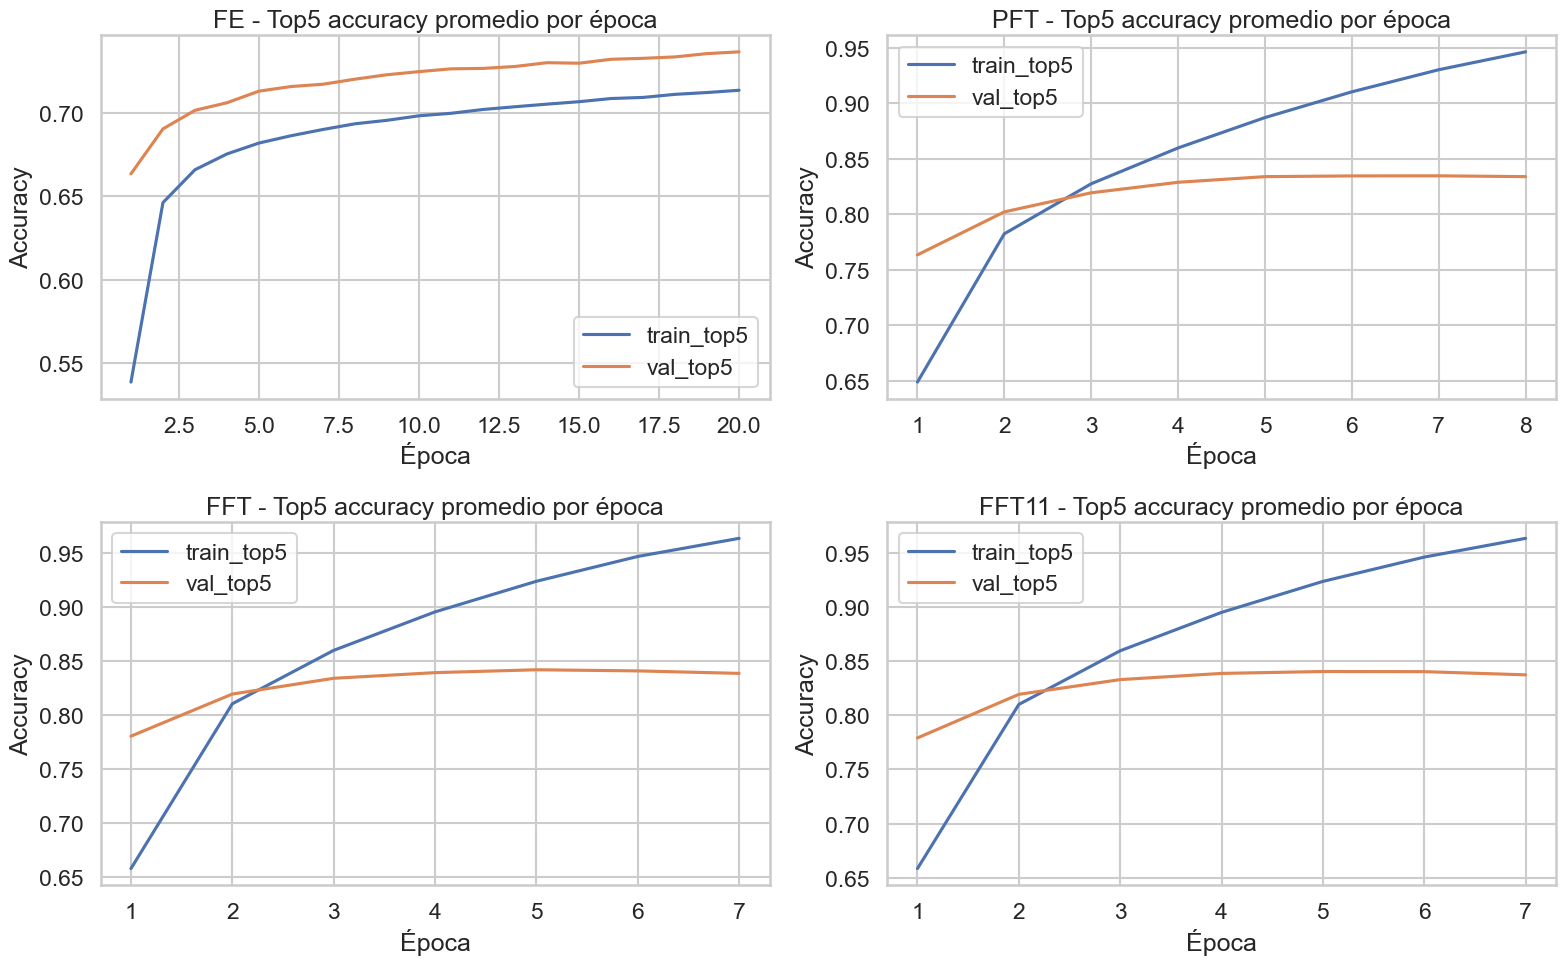

In [18]:
fig, axes = plt.subplots(2, 2, figsize=(16,10), sharex=False)
axes = axes.flatten()
for ax, train_type in zip(axes, ['FE','PFT','FFT','FFT11']):
    df = dist_history[dist_history['train_type']==train_type]
    mean_by_epoch = df.groupby('epoch')[['train_top5_acc','val_top5_acc']].mean().reset_index()
    sns.lineplot(data=mean_by_epoch, x='epoch', y='train_top5_acc', label='train_top5', ax=ax)
    sns.lineplot(data=mean_by_epoch, x='epoch', y='val_top5_acc', label='val_top5', ax=ax)
    ax.set_title(f'{train_type} - Top5 accuracy promedio por época')
    ax.set_xlabel('Época')
    ax.set_ylabel('Accuracy')
    ax.legend()
plt.tight_layout()
plt.show()


In [19]:
dist_history

,iteration,seed,epoch,train_loss,train_acc,train_top1_acc,train_top2_acc,train_top3_acc,train_top4_acc,train_top5_acc,val_loss,val_acc,val_top1_acc,val_top2_acc,val_top3_acc,val_top4_acc,val_top5_acc,train_type
0,1,491185480,1,3.556737,0.334933,0.334933,0.425275,0.476527,0.511922,0.539692,2.716067,0.446785,0.446785,0.547390,0.597655,0.635148,0.661438,FE
1,1,491185480,2,2.819426,0.424199,0.424199,0.526869,0.581612,0.618844,0.646599,2.554040,0.471581,0.471581,0.574352,0.626186,0.661214,0.686235,FE
2,1,491185480,3,2.694364,0.441761,0.441761,0.546139,0.601510,0.638354,0.665857,2.487311,0.478677,0.478677,0.586003,0.638360,0.671820,0.696318,FE
3,1,491185480,4,2.632907,0.450995,0.450995,0.555719,0.611675,0.647902,0.675378,2.452231,0.486743,0.486743,0.591829,0.645903,0.677198,0.702517,FE
4,1,491185480,5,2.590887,0.456527,0.456527,0.562853,0.618342,0.654208,0.681679,2.418344,0.498768,0.498768,0.599746,0.649862,0.680559,0.705280,FE
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
204,5,125430804,3,1.452311,0.677009,0.677009,0.775200,0.817328,0.842573,0.860054,1.675995,0.650534,0.650534,0.748600,0.788857,0.813504,0.832923,FFT11
205,5,125430804,4,1.180154,0.725297,0.725297,0.820253,0.859154,0.880916,0.895841,1.638293,0.664426,0.664426,0.754201,0.797670,0.821869,0.838001,FFT11
206,5,125430804,5,0.950174,0.770346,0.770346,0.858820,0.892807,0.911994,0.924239,1.686713,0.665994,0.665994,0.758757,0.797520,0.823811,0.840167,FFT11
207,5,125430804,6,0.755697,0.810084,0.810084,0.892304,0.921440,0.937042,0.946842,1.717071,0.673613,0.673613,0.758160,0.800060,0.823437,0.839420,FFT11


In [20]:
best_epoch_by_train = select_best_epoch_by_mean_over_runs(
    df_epochs=dist_history,           
    group_cols=["train_type"],       
    epoch_col="epoch",
    metric_col="val_top5_acc",
    agg="mean",                      
    tie_break="earliest",
    min_runs=3,                     
)

best_epoch_by_train

,train_type,best_epoch,best_mean_val_top5_acc,n_runs
0,FE,20,0.736545,5
1,FFT,5,0.841855,5
2,FFT11,5,0.840586,5
3,PFT,7,0.834640,5


In [21]:
dist_metrics_best = filter_metrics_to_best_epoch(
    df_metrics_epochs=dist_history, 
    best_epoch_df=best_epoch_by_train,
    group_cols=["train_type"],
    epoch_col="epoch",
)

dist_metrics_best

,iteration,seed,epoch,train_loss,train_acc,train_top1_acc,train_top2_acc,train_top3_acc,train_top4_acc,train_top5_acc,val_loss,val_acc,val_top1_acc,val_top2_acc,val_top3_acc,val_top4_acc,val_top5_acc,train_type,best_epoch
19,1,491185480,20,2.372412,0.488585,0.488585,0.596575,0.651389,0.687141,0.713635,2.264432,0.522817,0.522817,0.623945,0.674733,0.705729,0.730002,FE,20
39,2,954562093,20,2.375439,0.487167,0.487167,0.594833,0.649720,0.686173,0.712560,2.216730,0.534095,0.534095,0.635895,0.688625,0.723206,0.747479,FE,20
59,3,737166323,20,2.380619,0.487691,0.487691,0.595062,0.649617,0.685235,0.711934,2.238779,0.526402,0.526402,0.627455,0.678617,0.710135,0.735230,FE,20
79,4,31187689,20,2.359093,0.490315,0.490315,0.597656,0.652541,0.688594,0.715387,2.284670,0.523863,0.523863,0.625439,0.676301,0.710583,0.736351,FE,20
99,5,95156473,20,2.367814,0.489378,0.489378,0.596254,0.651295,0.687470,0.714136,2.273244,0.523415,0.523415,0.624318,0.673165,0.708716,0.733662,FE,20
106,1,550264748,7,0.923226,0.764890,0.764890,0.861023,0.897663,0.918132,0.931092,1.728835,0.663679,0.663679,0.755172,0.798417,0.821122,0.835537,PFT,7
113,2,140871553,7,0.922814,0.765086,0.765086,0.860499,0.897752,0.918000,0.930962,1.722309,0.663231,0.663231,0.758309,0.797894,0.820823,0.836284,PFT,7
121,3,420029892,7,0.939465,0.761866,0.761866,0.857011,0.894208,0.914657,0.928150,1.735619,0.660617,0.660617,0.753305,0.793487,0.817537,0.832997,PFT,7
129,4,320099395,7,0.934133,0.763678,0.763678,0.858848,0.896021,0.916434,0.929412,1.723698,0.665248,0.665248,0.750168,0.791993,0.816416,0.834043,PFT,7
137,5,748447230,7,0.921024,0.765454,0.765454,0.861449,0.898057,0.918234,0.931221,1.731641,0.662932,0.662932,0.752707,0.793861,0.817761,0.834342,PFT,7


## Performance DistilBERT

In [24]:
def make_topk_acc_view(df: pd.DataFrame, split: str = "val") -> pd.DataFrame:
    """
    Creates a view of df with columns top_1_acc..top_5_acc taken from:
      - val_top1_acc..val_top5_acc  if split="val"
      - train_top1_acc..train_top5_acc if split="train"

    Keeps all original columns too (adds/overwrites top_{k}_acc).
    """
    if split not in ("val", "train"):
        raise ValueError("split must be 'val' or 'train'")

    src_cols = [f"{split}_top{k}_acc" for k in range(1, 6)]
    missing = [c for c in src_cols if c not in df.columns]
    if missing:
        raise ValueError(f"Missing {split} top-k columns: {missing}")

    out = df.copy()
    rename_map = {f"{split}_top{k}_acc": f"top_{k}_acc" for k in range(1, 6)}
    out = out.rename(columns=rename_map)

    # ensure numeric
    for c in TOPK_COLS:
        out[c] = pd.to_numeric(out[c], errors="coerce")

    return out

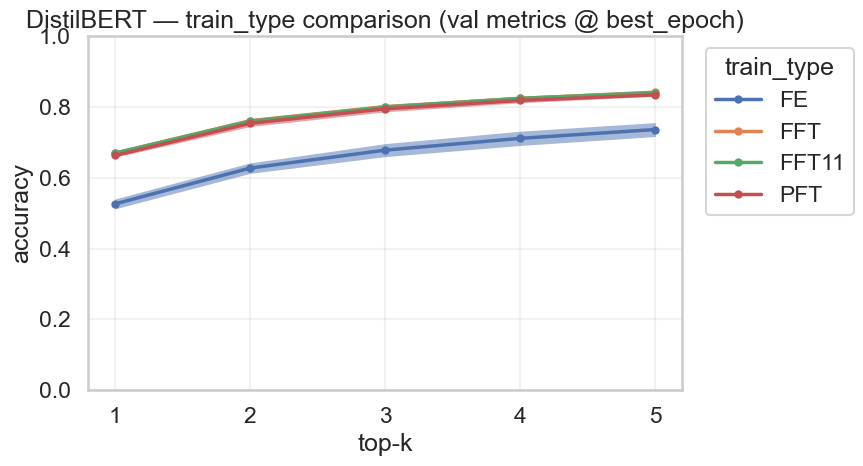

In [25]:
SPLIT_FOR_PLOTS = "val"
dist_metrics_best_view = make_topk_acc_view(dist_metrics_best, split=SPLIT_FOR_PLOTS)

dist_long = to_long_topk(
    dist_metrics_best_view,
    id_cols=["train_type", "iteration", "seed", "best_epoch"], 
    topk_cols=TOPK_COLS,
    acc_name="acc",
)

plot_topk_variability(
    dist_long,
    group_col="train_type",
    title=f"DistilBERT — train_type comparison ({SPLIT_FOR_PLOTS} metrics @ best_epoch)",
)

In [26]:
dist_summary = (
    dist_metrics
    .groupby('train_type')[['top_1_acc','top_2_acc','top_3_acc','top_4_acc','top_5_acc']]
    .agg(['mean','std','min','max'])
    .round(4)
)
dist_summary

top_1_acc                         top_2_acc                  \
                mean     std     min     max      mean     std     min   
train_type                                                               
FE            0.5267  0.0043  0.5234  0.5341    0.6286  0.0046  0.6243   
FFT           0.6627  0.0048  0.6545  0.6658    0.7569  0.0029  0.7536   
FFT11         0.6637  0.0015  0.6623  0.6660    0.7553  0.0020  0.7536   
PFT           0.6507  0.0028  0.6481  0.6552    0.7463  0.0027  0.7434   

                   top_3_acc                         top_4_acc          \
               max      mean     std     min     max      mean     std   
train_type                                                               
FE          0.6359    0.6793  0.0058  0.6732  0.6886    0.7124  0.0061   
FFT         0.7614    0.7977  0.0034  0.7924  0.8016    0.8228  0.0036   
FFT11       0.7579    0.7976  0.0019  0.7946  0.7997    0.8222  0.0017   
PFT         0.7503    0.7901  0.0029  0.7872  0.7939    0.8148  0.0023   

                           top_5_acc                          
               min     max      mean     std     min     max  
train_type                                                    
FE          0.7087  0.7232    0.7371  0.0060  0.7325  0.7475  
FFT         0.8170  0.8259    0.8392  0.0032  0.8343  0.8423  
FFT11       0.8198  0.8241    0.8388  0.0012  0.8374  0.8405  
PFT         0.8122  0.8175    0.8330  0.0020  0.8310  0.8361

## Performance DistilBERT vs. Baseline

In [27]:
best_dbert = "FFT"

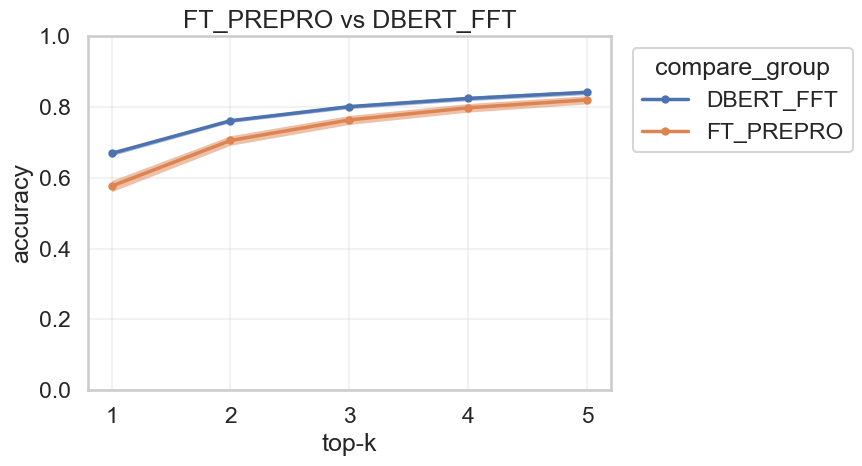

In [28]:
# Build an overlay DF (two "families"): best baseline + best distilbert train_type
baseline_best_long = baseline_long[baseline_long["family"] == best_baseline].copy()
baseline_best_long["compare_group"] = baseline_best_long["family"]

dist_best_long = dist_long[dist_long["train_type"] == best_dbert].copy()
dist_best_long["compare_group"] = "DBERT_" + dist_best_long["train_type"]

overlay = pd.concat(
    [
        baseline_best_long[["iteration", "topk", "acc", "compare_group"]],
        dist_best_long[["iteration", "topk", "acc", "compare_group"]],
    ],
    ignore_index=True,
)

plot_topk_variability(
    overlay,
    group_col="compare_group",
    title=f"{best_baseline} vs DBERT_{best_dbert}",
)

In [29]:
# Delta DF + summary

group_a = best_baseline
group_b = f"DBERT_{best_dbert}"

delta_long, delta_summary = build_delta_df(
    overlay,
    group_col="compare_group",
    group_a=group_a,
    group_b=group_b,
    iteration_col="iteration",
    x_col="topk",
    y_col="acc",
    delta_name="delta",
)

delta_summary

,topk,n,mean,std,median,q25,q75,min,max
0,1,5,0.092344,0.007203,0.093360,0.089327,0.095824,0.082007,0.101202
1,2,5,0.055000,0.004512,0.054971,0.054672,0.058108,0.047800,0.059452
2,3,5,0.036522,0.005896,0.034954,0.033535,0.041601,0.029129,0.043394
3,4,5,0.026126,0.006776,0.022854,0.021883,0.030174,0.019718,0.035999
4,5,5,0.020599,0.006177,0.019494,0.017178,0.024349,0.013071,0.028904


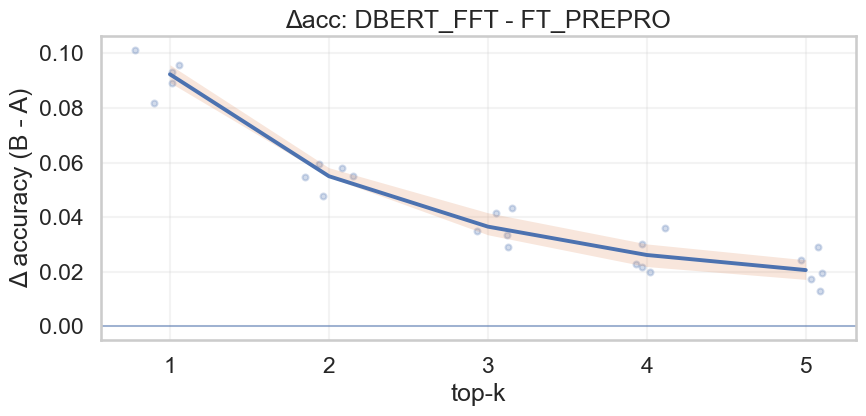

In [30]:
plot_delta_variability(
    delta_long,
    title=f"Δacc: {group_b} - {group_a}",
    mode="scatter",   # best when overlap is heavy
    band="iqr",
    jitter_x=0.10,
)

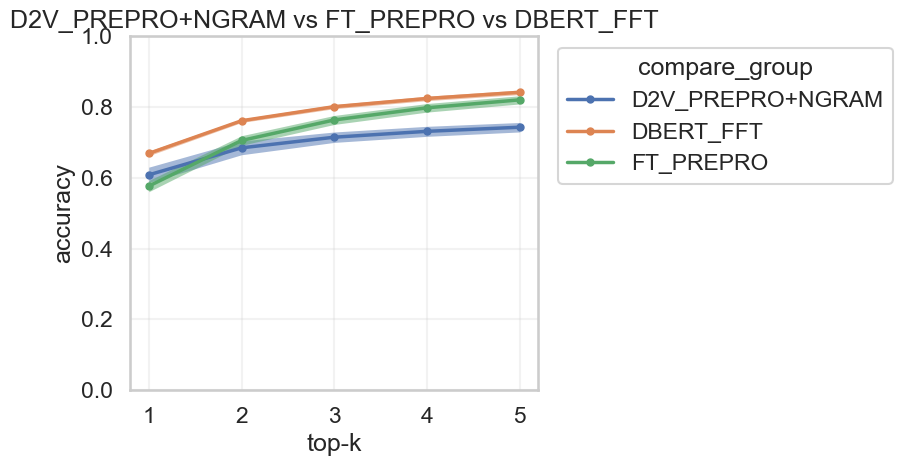

In [31]:
# Build an overlay DF (three "families"): 2 best baseline + best distilbert train_type
best_d2v_long = baseline_long[baseline_long["family"] == best_d2v].copy()
best_d2v_long["compare_group"] = best_d2v_long["family"]

best_ft_long = baseline_long[baseline_long["family"] == best_ft].copy()
best_ft_long["compare_group"] = best_ft_long["family"]

dist_best_long = dist_long[dist_long["train_type"] == best_dbert].copy()
dist_best_long["compare_group"] = "DBERT_" + dist_best_long["train_type"]

overlay = pd.concat(
    [
        best_d2v_long[["iteration", "topk", "acc", "compare_group"]],
        best_ft_long[["iteration", "topk", "acc", "compare_group"]],
        dist_best_long[["iteration", "topk", "acc", "compare_group"]],
    ],
    ignore_index=True,
)

plot_topk_variability(
    overlay,
    group_col="compare_group",
    title=f"{best_d2v} vs {best_ft} vs DBERT_{best_dbert}",
)

Porque dejo de ver la variabilidad en algunos modelos DBERT??